# SCI-150 Final Data Processing



In [723]:
# imports

import pandas as pd
import matplotlib.pyplot as plt

In [724]:
# Constants

city_names = ["Bakersfield", "Burlington", "Chicago", "Detroit", "ElPaso", "Fresno", "Visalia"]
efficiency_rates = {0: 0, 10: 0.77, 100: 5.72, 1000: 23.11}
pm_threshold = 9.0

In [725]:
# Helper functions and variables
efficiency_columns = [f"{count} filters" for count, _ in efficiency_rates.items()]

def get_city_name(df: pd.DataFrame) -> str:
    return df['City'].iloc[0]

def save_data(df: pd.DataFrame) -> None:
    df.to_csv(f"./data/output/{get_city_name(df)}.csv")


In [726]:
def get_dataframe(city: str) -> pd.DataFrame:
    df =  pd.read_csv(f"./data/import/{city}.csv")
    df['City'] = city

    return df


In [727]:
def filer_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    return df[['City', 'Date', 'Daily Mean PM2.5 Concentration', 'State', 'Local Site Name']]

In [728]:
def calculate_efficiency(df: pd.DataFrame) -> pd.DataFrame:
    efficiency_data = df
    for filter_count, efficiency in efficiency_rates.items():
        efficiency_data[f"{filter_count} filters"] = efficiency_data['Daily Mean PM2.5 Concentration'] * (1 - (efficiency / 100))

    return efficiency_data

In [729]:
def get_max_particle_count(df: pd.DataFrame) -> pd.DataFrame:
    idx = df.groupby('Date')['Daily Mean PM2.5 Concentration'].idxmax()
    max_data = df.iloc[idx]
    return max_data

In [730]:
def get_above_threshold_counts(df: pd.DataFrame) -> pd.DataFrame:
    passing_threshold = df

    for count, _ in efficiency_rates.items():
        passing_threshold[f'Below threshold with {count} filters'] = df[f'{count} filters'] <= pm_threshold

    return passing_threshold

In [731]:
def process_city(city: str):
    dataframe = get_dataframe(city)
    filtered_dataframe = filer_dataframe(dataframe)
    efficiency_data = calculate_efficiency(filtered_dataframe)
    max_data = get_max_particle_count(efficiency_data)
    threshold_data = get_above_threshold_counts(max_data)

    save_data(threshold_data)
    

    return threshold_data





In [732]:
all_city_data = [process_city(city) for city in city_names]

detroit_data = process_city("Detroit")
detroit_data.head()

,City,Date,Daily Mean PM2.5 Concentration,State,Local Site Name,0 filters,10 filters,100 filters,1000 filters,Below threshold with 0 filters,Below threshold with 10 filters,Below threshold with 100 filters,Below threshold with 1000 filters
2892,Detroit,01/01/2025,7.7,Michigan,Eliza Howell-NR,7.7,7.64071,7.25956,5.92053,True,True,True,True
2893,Detroit,01/02/2025,9.7,Michigan,Eliza Howell-NR,9.7,9.62531,9.14516,7.45833,False,False,False,True
2894,Detroit,01/03/2025,8.7,Michigan,Eliza Howell-NR,8.7,8.63301,8.20236,6.68943,True,True,True,True
2895,Detroit,01/04/2025,6.3,Michigan,Eliza Howell-NR,6.3,6.25149,5.93964,4.84407,True,True,True,True
2896,Detroit,01/05/2025,8.6,Michigan,Eliza Howell-NR,8.6,8.53378,8.10808,6.61254,True,True,True,True


In [733]:
def plot_line_graph(df: pd.DataFrame) -> None:
    df.plot(x='Date', y=efficiency_columns)
    plt.xlabel('Date')
    plt.ylabel('Calculated PM2.5 Particles by Filter Count')
    plt.title(f"PM2.5 Particle Count in {get_city_name(df)}")

    # throw a dashed line across y=9
    plt.axhline(y=pm_threshold, linestyle='--', linewidth=1)

    plt.show()

In [734]:
def get_city_true_counts(df: pd.DataFrame) -> pd.Series:
    cols = [f'Below threshold with {count} filters' for count, _ in efficiency_rates.items()]
    counts = df[cols].apply(pd.Series.value_counts).loc[True]
    # Shorten index labels for the x-axis: "Below threshold with 0 filters" -> "0"
    counts.index = [col.split()[3] for col in counts.index]
    return counts

In [735]:
def plot_passing_graph(all_city_data: list[pd.DataFrame]) -> None:
    combined = pd.DataFrame({
        get_city_name(df): get_city_true_counts(df)
        for df in all_city_data
    })

    ax = combined.plot(
        kind='bar',
        figsize=(10, 6),
        width=0.8,
        rot=0,  
    )

    ax.set_xlabel('Number of Filters')
    ax.set_ylabel('Days below threshold')
    ax.set_title('PM2.5 Particle Count below 9.0 with Different Amounts of Moss Wall Filters')
    ax.legend(title='City')
    plt.tight_layout()
    plt.show()

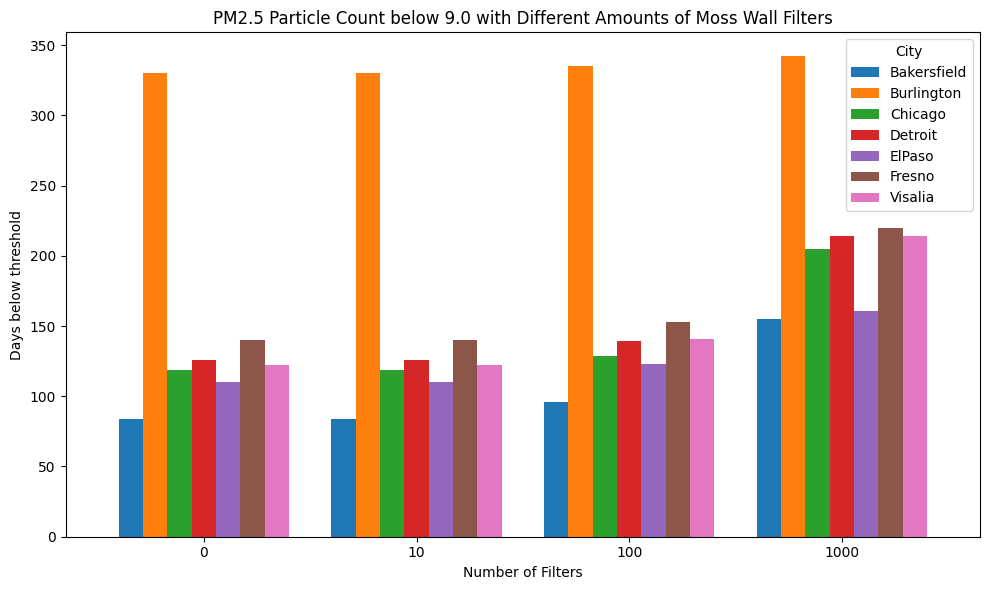

In [736]:
plot_passing_graph(all_city_data)